# Random Numbers and Simulation

exercises

In [2]:
import numpy as np
from fractions import Fraction
from functools import reduce, lru_cache, partial

import scipy as sp
from scipy import linalg as la
import scipy.optimize as opt
from scipy import special, interpolate, integrate
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial
np.set_printoptions(suppress=True, precision=6)

def sign(x):
    s = np.sign(x)
    return s if s else 1

In [3]:
# 13.1
# (a)
def congruent_rng(x0, a, b, M, n, verbose=False):
    i = 0
    x = x0
    history, printed = {x: i}, False
    for _ in range(n):
        i += 1
        x = (a * x + b) % M
        if x in history and not printed and verbose:
            print('period', i - history[x], 'repeat', x)
            printed = True
        history[x] = i
        yield x
        

x0 = 1
rng = congruent_rng(x0, 2, 0, 8192, n=10000, verbose=True)
len(list(rng));

period 1 repeat 0


In [4]:
# (b)
rng = congruent_rng(x0, 125, 0, 8192, n=10000, verbose=True)
len(list(rng));

period 2048 repeat 1


computer problems

In [5]:
# 13.1
def chi2_test(xs):
    for n in 10, 20:
        bins = np.linspace(0, 1, n+1)
        counts, bin_edges = np.histogram(xs, bins=bins)

        chi_stats = ((counts - k / n) ** 2 / (k / n)).sum()
        print('n', n, 'p', sp.stats.chi2.sf(chi_stats, n-1))
        

for k in range(100, 1001, 100):
    print('k', k)
    np.random.seed(0)
    xs = np.random.random(k)
    chi2_test(xs)

k 100
n 10 p 0.6371194071693984
n 20 p 0.8678232431976977
k 200
n 10 p 0.6683211702507843
n 20 p 0.6705777332945888
k 300
n 10 p 0.7727602750730935
n 20 p 0.8551895808078861
k 400
n 10 p 0.8942010951959319
n 20 p 0.8631560637880603
k 500
n 10 p 0.43727418891386693
n 20 p 0.5709048115566326
k 600
n 10 p 0.2535507297323109
n 20 p 0.5091178898707238
k 700
n 10 p 0.39868958534422233
n 20 p 0.35118172736455006
k 800
n 10 p 0.47498568664801
n 20 p 0.3767330333434422
k 900
n 10 p 0.7960593556023352
n 20 p 0.5492876966128322
k 1000
n 10 p 0.9060685891346634
n 20 p 0.8603149998350735


In [6]:
for k in range(100, 1001, 100):
    print('k', k)
    xs = list(congruent_rng(1, 2, 0, 8192, n=k))
    chi2_test(xs)

k 100
n 10 p 1.5270199098256477e-144
n 20 p 3.0509336700591604e-301
k 200
n 10 p 0.0
n 20 p 0.0
k 300
n 10 p 0.0
n 20 p 0.0
k 400
n 10 p 0.0
n 20 p 0.0
k 500
n 10 p 0.0
n 20 p 0.0
k 600
n 10 p 0.0
n 20 p 0.0
k 700
n 10 p 0.0
n 20 p 0.0
k 800
n 10 p 0.0
n 20 p 0.0
k 900
n 10 p 0.0
n 20 p 0.0
k 1000
n 10 p 0.0
n 20 p 0.0


In [7]:
def fibonacci_rng(seed, n):
    np.random.seed(seed)
    buffer = np.random.random(17)
    if n <= 17:
        yield from buffer[:n]
    else:
        yield from buffer
        i = 16
        for _ in range(n - 17):
            i += 1
            x = buffer[(i-17)%17] - buffer[(i-5)%17]
            x = x if sign(x) >= 0 else x + 1
            buffer[i%17] = x
            yield x
            
            

for k in range(100, 1001, 100):
    print('k', k)

    xs = list(fibonacci_rng(seed=0, n=k))
    # print(xs)
    chi2_test(xs)

k 100
n 10 p 0.40119928658025733
n 20 p 0.08342862398216526
k 200
n 10 p 0.10879095519400779
n 20 p 0.14172561773247278
k 300
n 10 p 0.015241005957541767
n 20 p 0.024469236554027593
k 400
n 10 p 0.026948185023042272
n 20 p 0.15727685750770876
k 500
n 10 p 0.026948185023042272
n 20 p 0.06535854422850136
k 600
n 10 p 0.04327421522232693
n 20 p 0.06391658417183117
k 700
n 10 p 0.2566319664483178
n 20 p 0.2286475195552709
k 800
n 10 p 0.3345381516340064
n 20 p 0.2417750877939656
k 900
n 10 p 0.3838265173713841
n 20 p 0.28425625866895426
k 1000
n 10 p 0.2675731830311526
n 20 p 0.3258558170509772


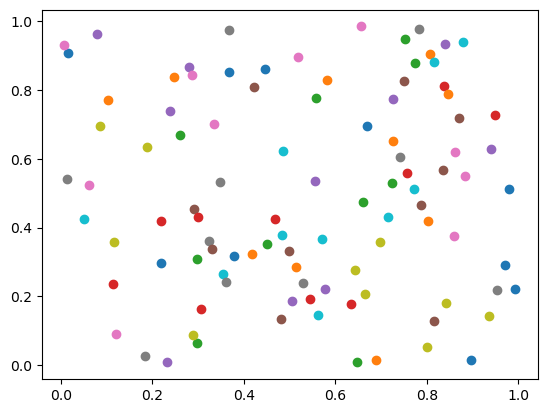

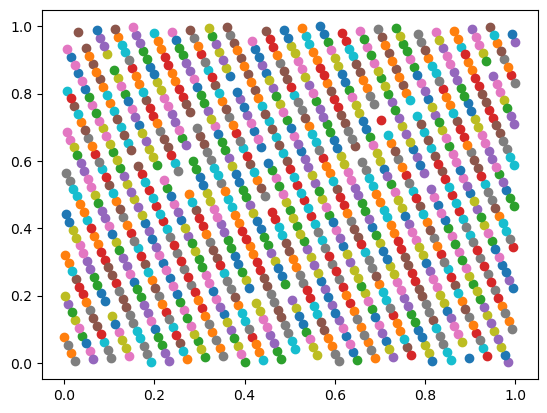

In [8]:
# 13.2
for n in 100, 1000:
    plt.figure()
    xs = np.array(list(congruent_rng(1, 125, 0, 8192, n=2*n))) / 8192
    for i in range(n):
        plt.scatter(xs[2*i], xs[2*i+1])

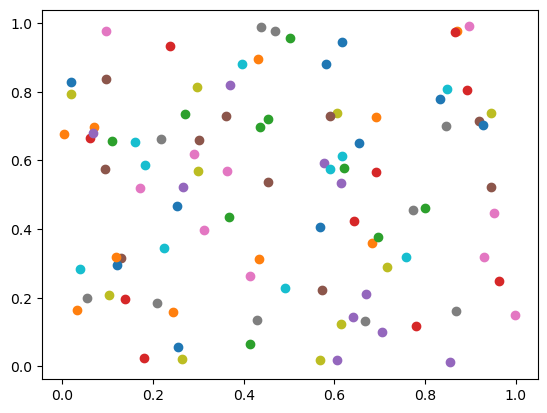

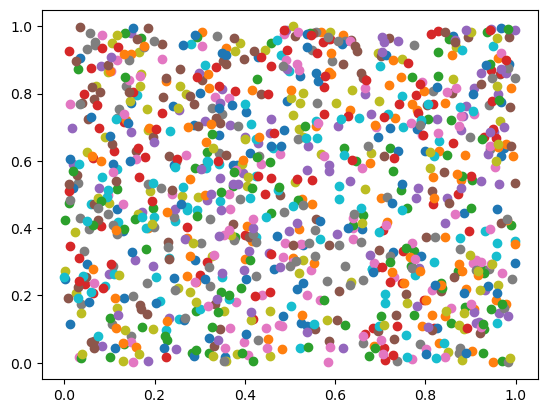

In [9]:
for n in 100, 1000:
    plt.figure()
    xs = np.random.random(2*n)
    for i in range(n):
        plt.scatter(xs[2*i], xs[2*i+1])

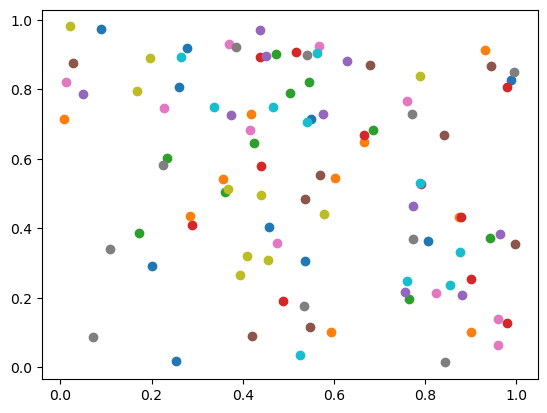

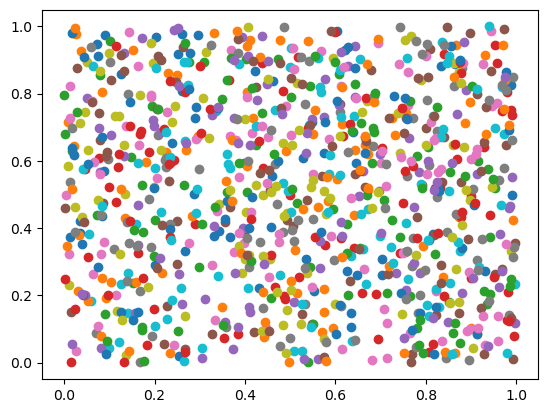

In [10]:
for n in 100, 1000:
    plt.figure()
    xs = list(fibonacci_rng(0, 2*n))
    for i in range(n):
        plt.scatter(xs[2*i], xs[2*i+1])

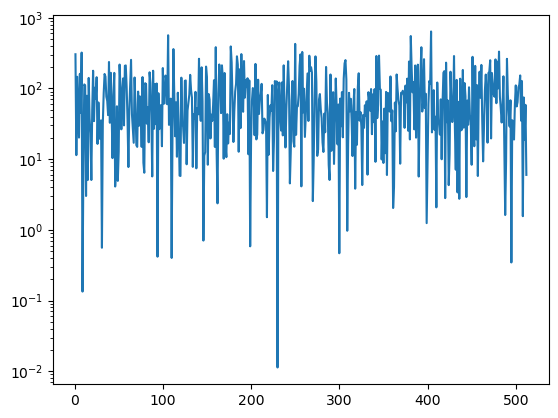

In [11]:
# 13.3
n = 1024
ys = np.abs(np.fft.fft(list(fibonacci_rng(0, n)))) ** 2
plt.semilogy(np.arange(1,n//2+1), ys[1:n//2+1])

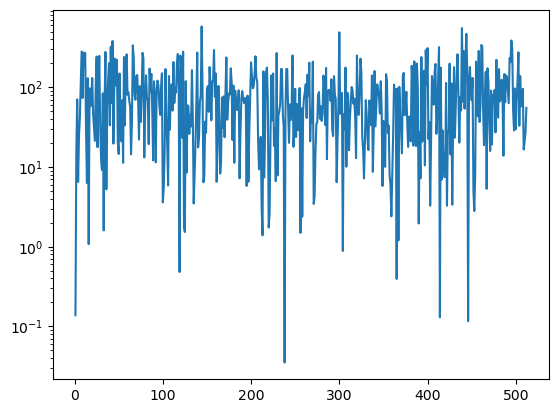

In [12]:
ys = np.abs(np.fft.fft(np.random.random(n))) ** 2
plt.semilogy(np.arange(1,n//2+1), ys[1:n//2+1])

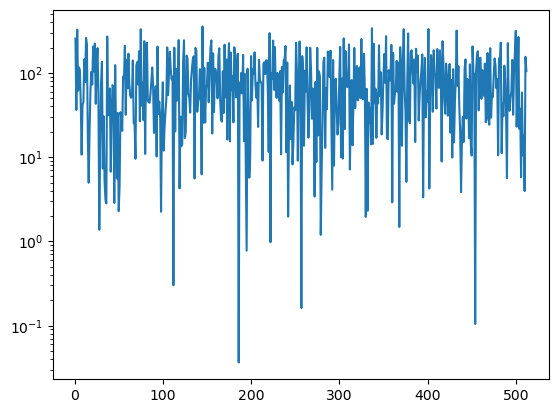

In [13]:
ys = np.abs(np.fft.fft(np.array(list(congruent_rng(1, 125, 0, 8192, n=n))) / 8192)) ** 2
plt.semilogy(np.arange(1,n//2+1), ys[1:n//2+1])

In [14]:
# 13.4
n = 1000
xs = np.array(list(congruent_rng(1, 125, 0, 8192, n=n))) / 8192
xs.mean(), xs.var() * 12

(np.float64(0.4994482421875), np.float64(1.0193905208587646))

In [15]:
xs = np.array(list(fibonacci_rng(0, n)))
xs.mean(), xs.var() * 12

(np.float64(0.5222921054878463), np.float64(0.9735311863460798))

In [16]:
xs = np.random.random(n)
xs.mean(), xs.var() * 12

(np.float64(0.4935671605149464), np.float64(1.0162176708546722))

In [17]:
# 13.5
from collections import Counter
from more_itertools import chunked

def pokerhand(xs):
    stats = Counter()
    hand = Counter()

    for cards in chunked(xs, 5):
        hand.clear()
        hand.update(cards)
        
        if len(hand) == 5:
            stats['bust'] += 1
        elif len(hand) == 4:
            stats['onepair'] += 1
        elif len(hand) == 3:
            if max(hand.values()) == 2:
                stats['twopair'] += 1
            else:
                stats['three'] += 1
        elif len(hand) == 2:
            if max(hand.values()) == 3:
                stats['fullhouse'] += 1
            else:
                stats['four'] += 1
        else:
            stats['five'] += 1
    return stats


size = 1000000 * 5
pokerhand(np.random.choice(10, size=size))

Counter({'onepair': 503223,
         'bust': 302718,
         'twopair': 107829,
         'three': 72587,
         'fullhouse': 9030,
         'four': 4504,
         'five': 109})

In [18]:
xs = (np.array(list(fibonacci_rng(0, size))) * 10).astype(int)
pokerhand(xs)

Counter({'onepair': 503308,
         'bust': 302970,
         'twopair': 108070,
         'three': 72156,
         'fullhouse': 8960,
         'four': 4410,
         'five': 126})

In [19]:
xs = (np.array(list(fibonacci_rng(0, size))) * 10).astype(int)
pokerhand(xs)

Counter({'onepair': 503308,
         'bust': 302970,
         'twopair': 108070,
         'three': 72156,
         'fullhouse': 8960,
         'four': 4410,
         'five': 126})

In [20]:
xs = (np.array(list(congruent_rng(1, 125, 0, 8192, n=size))) / 8192 * 10).astype(int)
pokerhand(xs)

Counter({'onepair': 505863,
         'bust': 306638,
         'twopair': 94724,
         'three': 80080,
         'four': 7812,
         'fullhouse': 4883})

In [21]:
# 13.6
def same_birthday_probability(xs, n):
    s = t = 0
    for bs in chunked(xs, n):
        if len(bs) < n:
            break
        t += 1
        # print(len(set(bs)))
        if len(set(bs)) < n:
            s += 1
    return round(s / t, 4)



size = 100000
for n in 5, 10, 15, 20, 21, 22, 23, 24, 25:
    print(n, same_birthday_probability(np.random.choice(365, size=size), n))

5 0.0268
10 0.1224
15 0.2495
20 0.4044
21 0.4449
22 0.4717
23 0.51
24 0.5415
25 0.5617


In [22]:
# 13.7
def realroots_probability(xs):
    s = t = 0
    for cs in chunked(xs, 3):
        if len(cs) < 3:
            break
        t += 1
        a, b, c = cs
        if b ** 2 >= 4 * a * c:
            s += 1
    return round(s / t, 4)


size = 100000
realroots_probability(np.random.uniform(-1, 1, size=size))

0.6292

Theoretical percentages (bins: (-∞,-2), [-2,-1), [-1,0), [0,1), [1,2), [2,∞)):
['2.28%', '13.59%', '34.13%', '34.13%', '13.59%', '2.28%']

Observed percentages:
CLT method      : ['2.20%', '14.00%', '35.80%', '32.20%', '14.30%', '1.50%']
Box-Muller      : ['1.80%', '12.10%', '34.30%', '33.20%', '15.90%', '2.70%']
Marsaglia       : ['1.90%', '13.30%', '36.60%', '33.20%', '13.50%', '1.50%']
Library (Numpy) : ['2.60%', '12.40%', '34.60%', '34.40%', '13.40%', '2.60%']


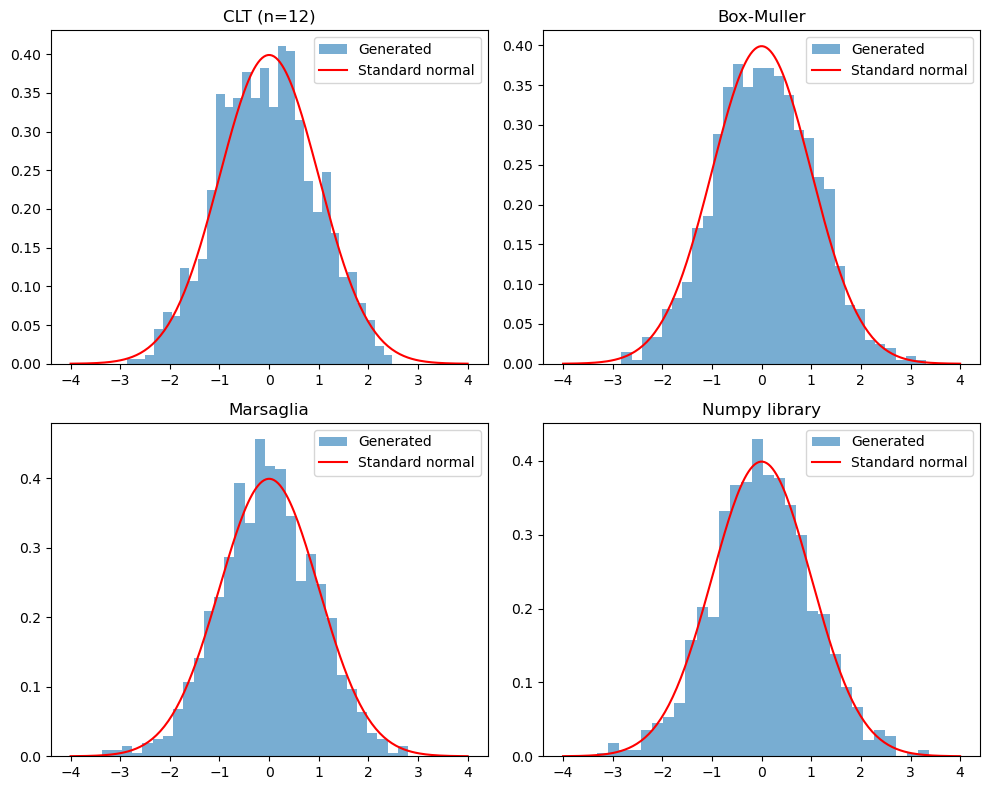

In [23]:
# 12.8 by deepseek
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ------------------------------
# 1. CLT method (n=12)
def clt_normal(n_samples=1):
    """Return n_samples standard normal variates using CLT with n=12."""
    samples = np.zeros(n_samples)
    for i in range(n_samples):
        u = np.random.uniform(0, 1, 12)
        samples[i] = u.sum() - 6.0
    return samples

# 2. Box-Muller method
def box_muller_normal(n_samples):
    """Return n_samples standard normal variates (n_samples must be even)."""
    if n_samples % 2 != 0:
        n_samples += 1
    normals = np.zeros(n_samples)
    for i in range(0, n_samples, 2):
        u1 = np.random.uniform(0, 1)
        u2 = np.random.uniform(0, 1)
        r = np.sqrt(-2.0 * np.log(u1))
        theta = 2.0 * np.pi * u2
        normals[i] = r * np.cos(theta)
        normals[i+1] = r * np.sin(theta)
    return normals[:n_samples] if n_samples % 2 == 0 else normals[:-1]

# 3. Marsaglia polar method
def marsaglia_normal(n_samples):
    """Return n_samples standard normal variates."""
    normals = []
    while len(normals) < n_samples:
        x = np.random.uniform(-1, 1)
        y = np.random.uniform(-1, 1)
        r2 = x*x + y*y
        if 0 < r2 < 1:
            factor = np.sqrt(-2.0 * np.log(r2) / r2)
            normals.append(x * factor)
            if len(normals) < n_samples:
                normals.append(y * factor)
    return np.array(normals[:n_samples])

# ------------------------------
# Test parameters
n = 1000
bins = [-np.inf, -2, -1, 0, 1, 2, np.inf]   # bin edges
theoretical = [norm.cdf(-2), 
               norm.cdf(-1)-norm.cdf(-2),
               norm.cdf(0)-norm.cdf(-1),
               norm.cdf(1)-norm.cdf(0),
               norm.cdf(2)-norm.cdf(1),
               1-norm.cdf(2)]
theoretical_pct = [100*p for p in theoretical]

print("Theoretical percentages (bins: (-∞,-2), [-2,-1), [-1,0), [0,1), [1,2), [2,∞)):")
print([f"{p:.2f}%" for p in theoretical_pct])

# Generate samples
np.random.seed(42)   # for reproducibility
clt_samples = clt_normal(n)
bm_samples = box_muller_normal(n)
mars_samples = marsaglia_normal(n)
lib_samples = np.random.normal(0, 1, n)   # library routine

# Compute histograms
def bin_percentages(samples, bins):
    counts, _ = np.histogram(samples, bins=bins)
    return 100 * counts / len(samples)

clt_pct = bin_percentages(clt_samples, bins)
bm_pct = bin_percentages(bm_samples, bins)
mars_pct = bin_percentages(mars_samples, bins)
lib_pct = bin_percentages(lib_samples, bins)

print("\nObserved percentages:")
print("CLT method      :", [f"{p:.2f}%" for p in clt_pct])
print("Box-Muller      :", [f"{p:.2f}%" for p in bm_pct])
print("Marsaglia       :", [f"{p:.2f}%" for p in mars_pct])
print("Library (Numpy) :", [f"{p:.2f}%" for p in lib_pct])

# Plot histograms
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
methods = [("CLT (n=12)", clt_samples), ("Box-Muller", bm_samples),
           ("Marsaglia", mars_samples), ("Numpy library", lib_samples)]

for ax, (name, data) in zip(axes.flat, methods):
    ax.hist(data, bins=30, density=True, alpha=0.6, label='Generated')
    x = np.linspace(-4, 4, 200)
    ax.plot(x, norm.pdf(x), 'r-', label='Standard normal')
    ax.set_title(name)
    ax.legend()
plt.tight_layout()
plt.show()

In [24]:
# 13.9
n = 100000
y = np.random.uniform(0, .5, n)
theta = np.random.uniform(0, np.pi / 2, n)
2 * n /(y <= np.sin(theta) / 2).sum()

np.float64(3.1348453737519395)

In [25]:
# 13.10
# (a)
n = 10000
x = np.random.random(n)
y = np.random.random(n)
((x - .5) ** 2 + (y - .5) ** 2 <= .25).sum() / n, np.pi / 4


(np.float64(0.7778), 0.7853981633974483)

In [26]:
n = 10000
x = np.random.random(n)
y = np.random.random(n)
z = np.random.random(n)
((x - .5) ** 2 + (y - .5) ** 2 + (z - .5) ** 2 <= .25).sum() / n, np.pi / 6

(np.float64(0.5265), 0.5235987755982988)

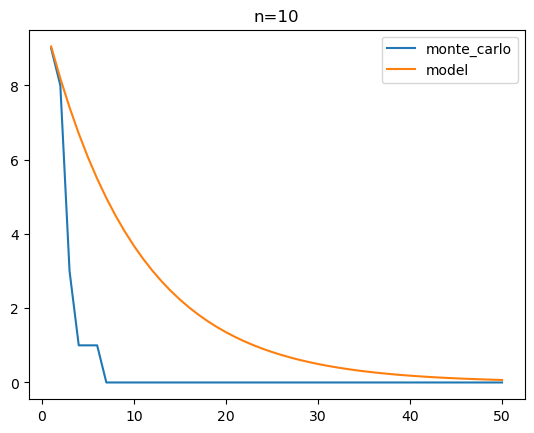

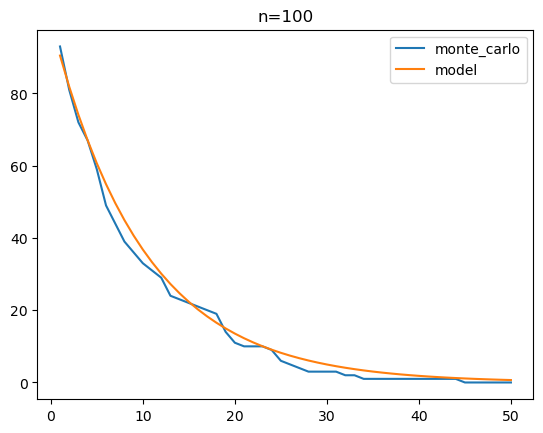

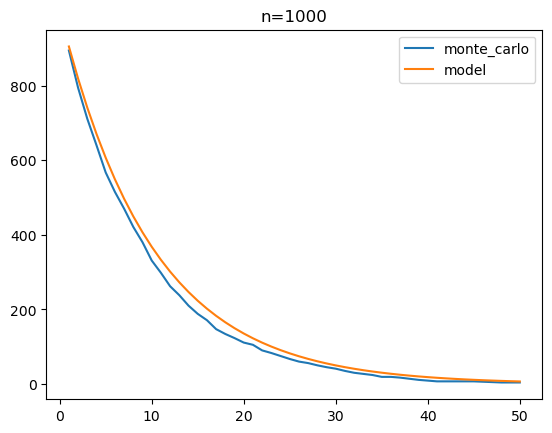

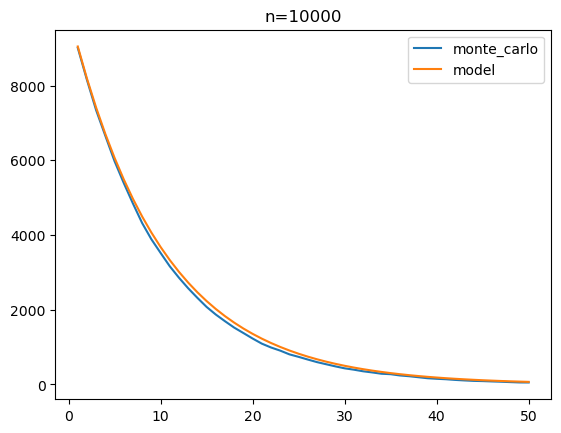

In [27]:
# 13.12
lam, m = .1, 50

for n in 10, 100, 1000, 10000:
    plt.figure()
    atoms = (np.random.random((n, m)) > lam).cumprod(axis=1)
    plt.plot(range(1, 51), atoms.sum(axis=0), label='monte_carlo')
    plt.plot(range(1, 51), n * np.exp(-lam * np.arange(1, 51)), label='model')
    plt.legend()
    plt.title(f'n={n}')

In [28]:
# 13.13
size = 10000
for n in 10, 100, 1000, 10000:
    distance = []
    for _ in range(size):
        left = np.random.uniform(-1, 1, n) < 0
        steps = np.ones(n)
        steps[left] = -1
        distance.append(np.abs(steps.sum()))
    print('n', n, 'distance', np.mean(distance))

n 10 distance 2.4692
n 100 distance 7.993
n 1000 distance 25.1494
n 10000 distance 79.3084


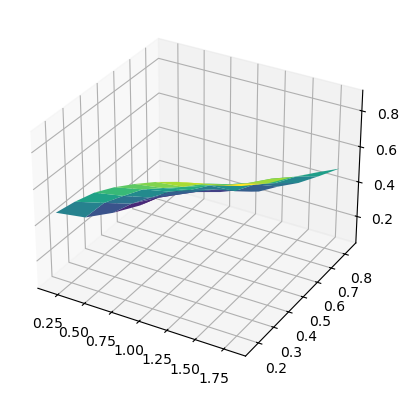

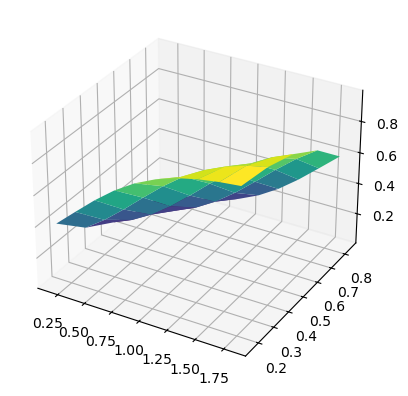

In [42]:
# 13.15
def h(t, x):
    v = .1
    return 1 / (1 + np.exp(x / (2 * v) - t / (4 * v)))


def u(t0, x0, dx, dt):
    ys = []
    for _ in range(2000):
        t, x = t0, x0
        while True:
            left_down = np.random.uniform(-1, 1, 2) < 0
            directions = np.ones(2)
            directions[left_down] = -1
            t, x = directions * [dt, dx] + [t, x]
            if np.isclose(t, 0) or np.isclose(x, 0) or np.isclose(x, 1):
                break
        ys.append(h(t, x))
    return np.mean(ys)


n = 5
t = np.linspace(0, 2, 2*n + 2)[1:-1]
x = np.linspace(0, 1, n+2)[1:-1]

T, X = np.meshgrid(t, x)
Y = np.zeros_like(T)
for i in range(len(Y)):
    for j in range(len(Y[0])):
        Y[i, j] = u(T[i, j], X[i, j], dx=x[1]-x[0], dt=t[1]-t[0])


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(T, X, Y, cmap='viridis', edgecolor='none')

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(T, X, h(T, X), cmap='viridis', edgecolor='none')

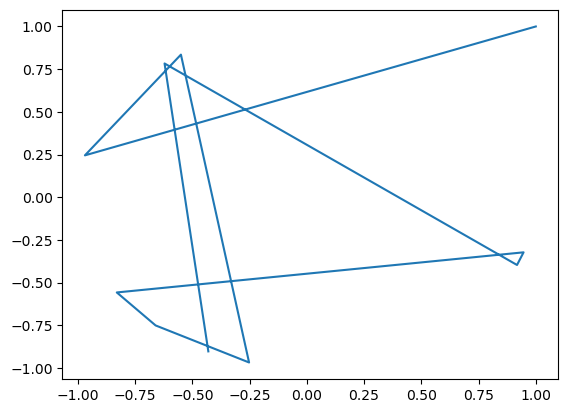

In [51]:
# 13.15
# (a)
n = 10
theta = np.random.uniform(0, 2 * np.pi, n-1)
x = np.concatenate([[1], np.cos(theta)])
y = np.concatenate([[1], np.sin(theta)])
plt.plot(x, y)

In [52]:
for n in 10, 100, 1000:
    distance = []
    for _ in range(1000):
        x, y = 1, 0
        theta = np.random.uniform(0, 2 * np.pi, n-1)
        x += np.cos(theta).sum()
        y += np.sin(theta).sum()
        distance.append(la.norm([x, y]))
    print('n', n, 'distance', np.mean(distance))

n 10 distance 2.8440053238066803
n 100 distance 8.752525840543594
n 1000 distance 27.83492678096105


In [54]:
for n in 10, 100, 1000:
    distance = []
    for _ in range(1000):
        x, y, z = 1, 0, 0
        phi = np.random.uniform(0, np.pi, n-1)
        theta = np.random.uniform(0, 2 * np.pi, n-1)
        x += (np.sin(phi) * np.cos(theta)).sum()
        y += (np.sin(phi) * np.sin(theta)).sum()
        z += np.cos(phi).sum()
        distance.append(la.norm([x, y, z]))
    print('n', n, 'distance', np.mean(distance))

n 10 distance 2.9349389747260815
n 100 distance 9.392324651263163
n 1000 distance 28.9566395823203


In [59]:
for n in 10, 100, 1000:
    distance = []
    for _ in range(1000):
        x, y, z = 1, 0, 0
        phi = np.random.uniform(0, np.pi, n-1)
        theta = np.ones(n-1) * (109 / 180 * np.pi)
        x += (np.sin(phi) * np.cos(theta)).sum()
        y += (np.sin(phi) * np.sin(theta)).sum()
        z += np.cos(phi).sum()
        distance.append(la.norm([x, y, z]))
    print('n', n, 'distance', np.mean(distance))

n 10 distance 5.817452130374065
n 100 distance 63.297435611585534
n 1000 distance 637.0081946570374


In [64]:
# 13.16
trials = []
for _ in range(1000):
    x = np.cos(np.random.uniform(0, np.pi / 2))
    x += np.cos(np.random.uniform(0, np.pi, 7)).sum()
    trials.append(x >= 4)

sum(trials) / len(trials)

np.float64(0.042)

In [77]:
# 8.16
# (a)
from scipy.stats import qmc

sampler = qmc.Sobol(d=2, scramble=True) 
samples = sampler.random(n=1<<14)

np.exp(-samples[:, 0] * samples[:, 1]).mean()

np.float64(0.7965996000517559)

In [83]:
trials = []
for x, y in samples:
    if x ** 2 + y ** 2 < 1:
        trials.append(np.exp(- x * y))

np.mean(trials) * np.pi / 4

np.float64(0.6751818245685736)